In [1]:
# Импорты и базовые настройки эксперимента.

# - Фиксируем RANDOM_STATE, чтобы случайные компоненты были воспроизводимыми.
# - Создаём папку artifacts/ – туда будем складывать результаты и модель.
import os
from __future__ import annotations

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts dir:", ARTIFACTS_DIR.resolve())

Artifacts dir: C:\Users\Gobli\test3\HW06\artifacts


In [2]:
# Вспомогательные функции для эксперимента.

# Здесь нет “обучения” – только сервисные вещи:
# - compute_metrics: считает метрики (accuracy, F1, ROC-AUC при наличии вероятностей)
# - evaluate_on_test: единообразная оценка модели на тесте
# - save_json: аккуратное сохранение артефактов
# - plot_confusion / plot_roc: быстрая диагностика качества

def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
    }
    if y_proba is not None:
        try:
            m["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            m["roc_auc"] = None
    else:
        m["roc_auc"] = None
    return m

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, proba)
    metrics["model"] = label
    return metrics

def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.show()

def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.show()

2.3.1.2-3

In [3]:
df1 = pd.read_csv("S06-hw-dataset-01.csv")
df1.head()

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [4]:
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


In [5]:
df1['target'].value_counts(normalize=True)

target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

2.3.1.4 - Признаки и таргет

In [6]:
# - stratify=y сохраняет пропорции классов в train и test
# - random_state фиксирует случайность разбиения
X = df1.drop(['target', 'id'], axis=1)  # Удаляение target и id из признаков
y = df1['target']  # Целевая переменная
feature_names = X.columns.tolist()

2.3.2.1-2 Разделение данных на train/test

In [7]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape

((9000, 28), (3000, 28))

Почему важны фиксированный seed и стратификация? Фиксированный seed используется для воспроизводимости эксперементов, а стратификация нужна для обеспечения одинакового соотношения классов в тестовой и обучающих выборках.

2.3.3. Baseline’ы

In [8]:
# Baseline'ы и подготовка контейнеров для результатов.

# - results: список словарей с метриками на тесте
# - best_models: сюда складываем обученные лучшие модели (чтобы потом их диагностировать/сохранить)
# - search_summaries: сюда складываем лучшие параметры подбора и CV-оценку

# CV = кросс-валидация на train: нужна для подбора гиперпараметров без доступа к тесту.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
best_models = {}  # label -> fitted best estimator
search_summaries = {}  # label -> краткая инфа о подборе

# 2.1 Dummy baseline (без подбора)

# Dummy baseline: помогает понять, что модель вообще умеет что-то лучше «угадайки».
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
results.append(evaluate_on_test(dummy, X_test, y_test, "Dummy(most_frequent)"))
best_models["Dummy(most_frequent)"] = dummy

# 2.2 LogisticRegression baseline (с минимальным подбором)

# Логрегрессия почти всегда требует масштабирования признаков, поэтому используем Pipeline со StandardScaler.
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
])


# Подбираем C (обратная сила регуляризации): меньше C -> сильнее регуляризация -> проще модель.
lr_grid = {
    "lr__C": [0.1, 1.0, 10.0],
    "lr__penalty": ["l2"],
    "lr__solver": ["lbfgs"],
}


# GridSearchCV перебирает сетку параметров и оценивает качество по CV. scoring=roc_auc – метрика для бинарной классификации по вероятностям.
lr_search = GridSearchCV(
    lr, lr_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)
lr_search.fit(X_train, y_train)

best_lr = lr_search.best_estimator_
best_models["LogReg(scaled)"] = best_lr

search_summaries["LogReg(scaled)"] = {
    "best_params": lr_search.best_params_,
    "best_cv_roc_auc": float(lr_search.best_score_),
}

results.append(evaluate_on_test(best_lr, X_test, y_test, "LogReg(scaled)"))

search_summaries["LogReg(scaled)"]

{'best_params': {'lr__C': 10.0, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'},
 'best_cv_roc_auc': 0.8822238806908922}

2.3.4. Модели недели 6

In [9]:
# Единая функция для подбора гиперпараметров через GridSearchCV.

# Она:
# - обучает GridSearchCV на X_train/y_train
# - кладёт лучшую модель и summary в словари
# - добавляет финальную оценку на тесте в results

def run_search(label: str, estimator, param_grid: dict):
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    search.fit(X_train, y_train)

    best = search.best_estimator_
    best_models[label] = best
    search_summaries[label] = {
        "best_params": search.best_params_,
        "best_cv_roc_auc": float(search.best_score_),
    }
    results.append(evaluate_on_test(best, X_test, y_test, label))
    return search

In [10]:
# Decision Tree: одна модель дерева решений.

# Что обычно делает дерево “сложнее” и склоннее к переобучению:
# - большой max_depth
# - маленький min_samples_leaf
# ccp_alpha – параметр cost-complexity pruning (штраф за сложность).

# 3.1 Decision Tree
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_grid = {
    "max_depth": [None], #3, 5, 8],
    "min_samples_leaf": [1],# 5, 10, 20],
    "ccp_alpha": [0.0]#, 0.001, 0.005, 0.01],
}

dt_search = run_search("DecisionTree", dt, dt_grid)
search_summaries["DecisionTree"]

{'best_params': {'ccp_alpha': 0.0, 'max_depth': None, 'min_samples_leaf': 1},
 'best_cv_roc_auc': 0.83659265269233}

In [11]:
# Random Forest: ансамбль деревьев (bagging).

# Идеи:
# - много деревьев (n_estimators) снижает дисперсию
# - max_features добавляет разнообразие деревьев (важно для ансамблей)
# - ограничения глубины/листа помогают контролировать переобучение

# 3.2 Random Forest
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=False
)

rf_grid = {
    "max_depth": [None], # 6, 10],
    "min_samples_leaf": [1], # 5, 10],
    "max_features": ["sqrt"] # , 0.5],
}

rf_search = run_search("RandomForest", rf, rf_grid)
search_summaries["RandomForest"]

{'best_params': {'max_depth': None,
  'max_features': 'sqrt',
  'min_samples_leaf': 1},
 'best_cv_roc_auc': 0.9684465802433795}

In [12]:
# AdaBoost: адаптивный бустинг (увеличивает вес ошибочных примеров).

# Ключевые "ручки":
# - n_estimators: количество базовых оценщиков (чем больше, тем лучше, но дольше)
# - learning_rate: вес каждого нового оценщика (меньше -> медленнее, но может улучшить обобщение)
# - base_estimator: базовый алгоритм (по умолчанию DecisionTreeClassifier с max_depth=1)

# 3.3 AdaBoost (адаптивный бустинг)
ada = AdaBoostClassifier(
    random_state=RANDOM_STATE
)

# Сетка параметров для AdaBoost
ada_grid = {
    "n_estimators": [50], #, 100, 200],
    "learning_rate": [0.5] #, 0.8, 1.0, 1.2]
}

ada_search = run_search("AdaBoost", ada, ada_grid)
search_summaries["AdaBoost"]

{'best_params': {'learning_rate': 0.5, 'n_estimators': 50},
 'best_cv_roc_auc': 0.8870150706097979}

Сводка результатов (test)¶

In [13]:
df = pd.DataFrame(results)

# сортировка: roc_auc (если есть) иначе accuracy
df_sorted = df.copy()
df_sorted["roc_auc_sort"] = df_sorted["roc_auc"].fillna(-1.0)
df_sorted = df_sorted.sort_values(["roc_auc_sort", "accuracy"], ascending=False).drop(columns=["roc_auc_sort"])

df_sorted

,accuracy,f1,roc_auc,model
3,0.934667,0.894283,0.970610,RandomForest
4,0.830000,0.702797,0.890971,AdaBoost
1,0.829667,0.714685,0.878905,LogReg(scaled)
2,0.856667,0.776739,0.834335,DecisionTree
0,0.676667,0.000000,0.500000,Dummy(most_frequent)


In [14]:
# Сохранение артефактов эксперимента в artifacts/.

# После выполнения этой ячейки можно открыть папку artifacts/ и увидеть:
# - metrics_test.json (итоговые метрики)
# - search_summaries.json (лучшие параметры подбора)

metrics_path = ARTIFACTS_DIR / "metrics_test.json"
search_path = ARTIFACTS_DIR / "search_summaries.json"
def aggregate_metrics(results_list: list) -> dict:
    metrics_dict = {}
    for res in results_list:
        model_name = res.pop("model")  # Убираем "model"
        metrics_dict[model_name] = res
    return metrics_dict
final_metrics = aggregate_metrics(results)

save_json(final_metrics, metrics_path)
save_json(search_summaries, search_path)


print(final_metrics)
print("Saved:", metrics_path)
print("Saved:", search_path)

{'Dummy(most_frequent)': {'accuracy': 0.6766666666666666, 'f1': 0.0, 'roc_auc': 0.5}, 'LogReg(scaled)': {'accuracy': 0.8296666666666667, 'f1': 0.7146845337800112, 'roc_auc': 0.878905083540704}, 'DecisionTree': {'accuracy': 0.8566666666666667, 'f1': 0.7767393561786086, 'roc_auc': 0.8343354832156822}, 'RandomForest': {'accuracy': 0.9346666666666666, 'f1': 0.8942826321467098, 'roc_auc': 0.97060992331522}, 'AdaBoost': {'accuracy': 0.83, 'f1': 0.7027972027972028, 'roc_auc': 0.8909707480574882}}
Saved: artifacts\metrics_test.json
Saved: artifacts\search_summaries.json


In [15]:
# Выбор “лучшей” модели по таблице результатов.

# Важно: мы НЕ переобучаем и не меняем модель по тесту.
# Мы только выбираем, какую модель будем диагностировать и сохранять.

best_row = df_sorted.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

best_label, best_row.to_dict()

('RandomForest',
 {'accuracy': 0.9346666666666666,
  'f1': 0.8942826321467098,
  'roc_auc': 0.97060992331522,
  'model': 'RandomForest'})

Построение и сохранение графиков

In [16]:
os.makedirs("artifacts/figures", exist_ok=True)

def plot_confusion(y_true, y_pred, title: str, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    
    # Сохраняем график, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"График сохранен: {save_path}")
    
    plt.show()

def plot_roc(model, X_test, y_test, title: str, save_path=None):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    
    # Сохраняем график, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"График сохранен: {save_path}")
    
    plt.show()
confusion_save_path = "artifacts/figures/confusion_matrix.png"
roc_save_path = "artifacts/figures/roc_curve.png"

График сохранен: artifacts/figures/confusion_matrix.png


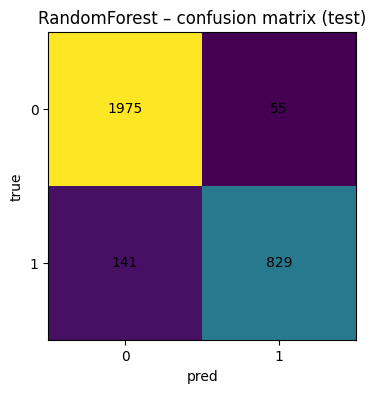

График сохранен: artifacts/figures/roc_curve.png


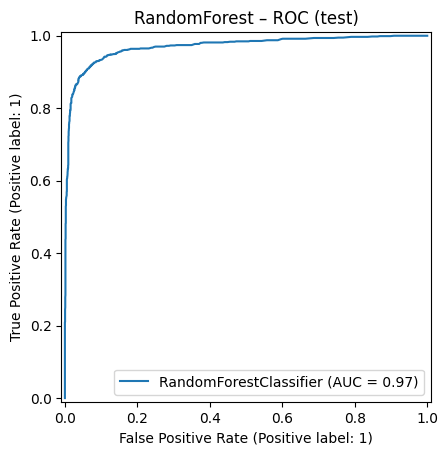

In [17]:
os.makedirs("artifacts/figures", exist_ok=True)

def plot_confusion(y_true, y_pred, title: str, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    
    # Сохраняем график, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"График сохранен: {save_path}")
    
    plt.show()

def plot_roc(model, X_test, y_test, title: str, save_path=None):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    
    # Сохраняем график, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"График сохранен: {save_path}")
    
    plt.show()

# Диагностика на тесте: confusion matrix и ROC-кривая
y_pred = best_model.predict(X_test)

# Пути для сохранения графиков
confusion_save_path = "artifacts/figures/confusion_matrix.png"
roc_save_path = "artifacts/figures/roc_curve.png"

# Построение и сохранение графиков
plot_confusion(y_test, y_pred, 
               title=f"{best_label} – confusion matrix (test)",
               save_path=confusion_save_path)

plot_roc(best_model, X_test, y_test, 
         title=f"{best_label} – ROC (test)",
         save_path=roc_save_path)

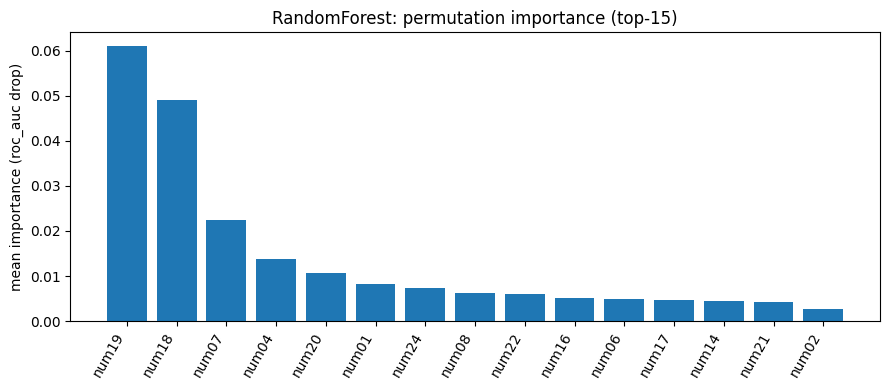

In [18]:
# Permutation importance на тесте (top-15).

# Идея: перемешиваем один признак и смотрим, насколько падает качество.
# Чем больше падение, тем “важнее” признак для модели.

scoring = "roc_auc" if hasattr(best_model, "predict_proba") else "accuracy"

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring=scoring
)

imp = perm.importances_mean
idx = np.argsort(imp)[::-1][:15]

plt.figure(figsize=(9, 4))
plt.bar(range(len(idx)), imp[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel(f"mean importance ({scoring} drop)")
plt.title(f"{best_label}: permutation importance (top-15)")
plt.tight_layout()
plt.show()

In [19]:
# Сохранение лучшей модели и метаданных.

# - best_model.joblib: сериализованная модель
# - best_model_meta.json: “паспорт” результата (какая модель, какие метрики, какие параметры)

model_path = ARTIFACTS_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)

meta = {
    "best_model_label": best_label,
    "test_metrics": best_row.to_dict(),
    "search_summary": search_summaries.get(best_label, None),
    "random_state": RANDOM_STATE,
}
save_json(meta, ARTIFACTS_DIR / "best_model_meta.json")

print("Saved:", model_path)
print("Saved:", ARTIFACTS_DIR / "best_model_meta.json")

Saved: artifacts\best_model.joblib
Saved: artifacts\best_model_meta.json


In [20]:
results

[{'accuracy': 0.6766666666666666, 'f1': 0.0, 'roc_auc': 0.5},
 {'accuracy': 0.8296666666666667,
  'f1': 0.7146845337800112,
  'roc_auc': 0.878905083540704},
 {'accuracy': 0.8566666666666667,
  'f1': 0.7767393561786086,
  'roc_auc': 0.8343354832156822},
 {'accuracy': 0.9346666666666666,
  'f1': 0.8942826321467098,
  'roc_auc': 0.97060992331522},
 {'accuracy': 0.83, 'f1': 0.7027972027972028, 'roc_auc': 0.8909707480574882}]

In [21]:
best_models

{'Dummy(most_frequent)': DummyClassifier(random_state=42, strategy='most_frequent'),
 'LogReg(scaled)': Pipeline(steps=[('scaler', StandardScaler()),
                 ('lr',
                  LogisticRegression(C=10.0, max_iter=4000, random_state=42))]),
 'DecisionTree': DecisionTreeClassifier(random_state=42),
 'RandomForest': RandomForestClassifier(n_estimators=600, n_jobs=-1, random_state=42),
 'AdaBoost': AdaBoostClassifier(learning_rate=0.5, random_state=42)}

In [22]:
meta

{'best_model_label': 'RandomForest',
 'test_metrics': {'accuracy': 0.9346666666666666,
  'f1': 0.8942826321467098,
  'roc_auc': 0.97060992331522,
  'model': 'RandomForest'},
 'search_summary': {'best_params': {'max_depth': None,
   'max_features': 'sqrt',
   'min_samples_leaf': 1},
  'best_cv_roc_auc': 0.9684465802433795},
 'random_state': 42}

In [23]:
#для проверки влияния/не влияния RANDOM_STATE на результаты
#for i in [42, 4, 17, 256, 14]:
 #   # 3.1 Decision Tree
  #  RANDOM_STATE = i
   # dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
#
 #   dt_grid = {
  #      "max_depth": [None, 3, 5, 8],
   #     "min_samples_leaf": [1, 5, 10, 20],
    #"ccp_alpha": [0.0, 0.001, 0.005, 0.01],
    #}

   # dt_search = run_search("DecisionTree", dt, dt_grid)
   # search_summaries["DecisionTree"]
#results